# Phase D - Typology-Harm Linkage (Index Scores)

This notebook links behavioural type to harm using Index Scores - the rate of a harm within a type divided by the population rate, scaled so 100 is the population average. Scores are computed from both the manual labels and the model predictions and their agreement is measured, validating the linkage.

**Input:** predictions and labels. **Output:** Index Score tables and the label-vs-prediction correlation.

# Loading predictions

In [1]:
import os, sys
import numpy as np, pandas as pd
os.chdir("/root/tf-project/venv/Projects/BehaviouralAnalysis")
sys.path.append("src")

PROC = "data/processed"
h = pd.read_parquet(f"{PROC}/harm_predictions.parquet")
print("posts:", len(h), "| types:", h.type.nunique())

TH = 0.5
for dim in ["para","bully","fin"]:
    h[f"pred_{dim}"] = (h[f"p_{dim}"] >= TH).astype(int)

posts: 2495 | types: 7


#  Computing Index Scores

For each type, the within-type harm rate is divided by the population rate and scaled so that 100 equals the population average and values above 100 indicate over-representation.

In [2]:
def index_scores(df, cols, prefix):
    base = {c: df[c].mean() for c in cols}
    rows = []
    for t, g in df.groupby("type"):
        row = {"type": t, "n": len(g)}
        for c in cols:
            rate = g[c].mean()
            row[f"{prefix}_{c}"] = round(rate / base[c] * 100, 1) if base[c] > 0 else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index("type")

idx_lab  = index_scores(h, ["y_para","y_bully","y_fin"], "L")
idx_pred = index_scores(h, ["pred_para","pred_bully","pred_fin"], "P")

print("=== INDEX SCORES (labels) ===")
print(idx_lab)
print("\n=== INDEX SCORES (predictions) ===")
print(idx_pred)
idx_lab.join(idx_pred.drop(columns="n")).to_csv(f"{PROC}/index_scores.csv")

=== INDEX SCORES (labels) ===
                                   n  L_y_para  L_y_bully  L_y_fin
type                                                              
Broadly Engaged                  289      97.1      130.9     44.0
Casual Participant               205      68.4       74.8     12.4
Conflict-Exposed                 652      70.7      221.1      7.8
Devoted                          289     201.1       35.4     35.2
Financially Intensive Collector  316     114.2       12.9    418.9
High-Intensity Multi-Domain      567      90.1       52.3     89.8
Peripheral                       177      90.6       46.2    201.4

=== INDEX SCORES (predictions) ===
                                   n  P_pred_para  P_pred_bully  P_pred_fin
type                                                                       
Broadly Engaged                  289         74.6         119.3        40.0
Casual Participant               205         76.8          92.0        11.3
Conflict-Exposed           

# Index Score heatmap

Scores from labels and from predictions are shown side by side.

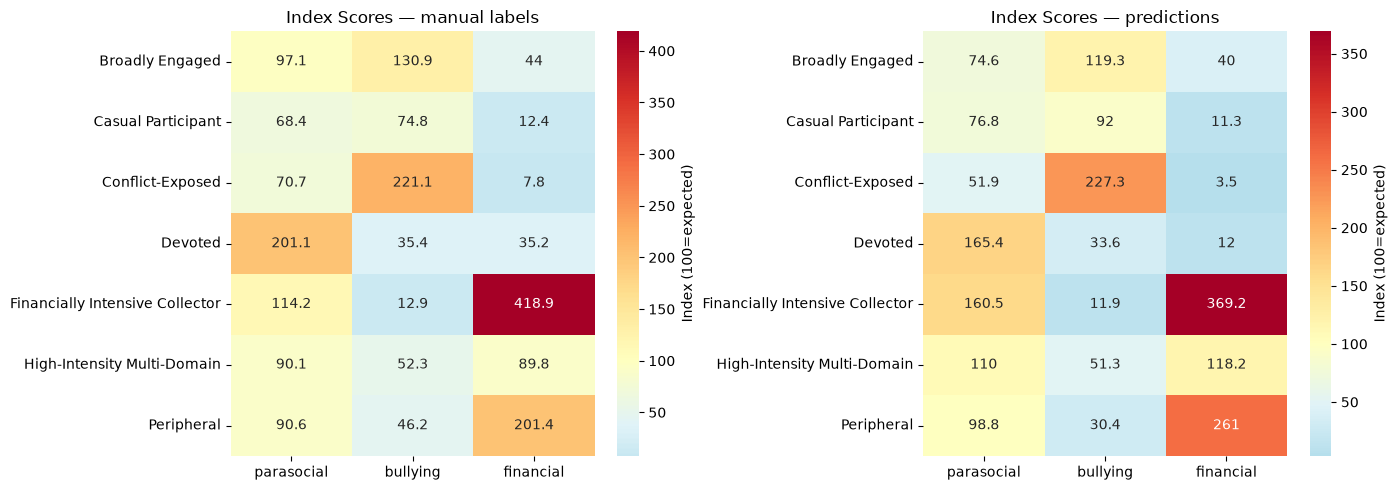

In [3]:
import matplotlib.pyplot as plt, seaborn as sns
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, idx, title, cols in [
    (a1, idx_lab, "Index Scores — manual labels", ["L_y_para","L_y_bully","L_y_fin"]),
    (a2, idx_pred, "Index Scores — predictions", ["P_pred_para","P_pred_bully","P_pred_fin"])]:
    m = idx[cols].copy(); m.columns = ["parasocial","bullying","financial"]
    sns.heatmap(m, annot=True, fmt="g", center=100, cmap="RdYlBu_r",
                cbar_kws={"label":"Index (100=expected)"}, ax=ax)
    ax.set_title(title); ax.set_ylabel("")
plt.tight_layout(); plt.savefig(f"{PROC}/index_heatmap.png", dpi=150); plt.show()

# Validation 

In [4]:
from scipy.stats import pearsonr
for L, P, name in [("L_y_para","P_pred_para","parasocial"),
                   ("L_y_bully","P_pred_bully","bullying"),
                   ("L_y_fin","P_pred_fin","financial")]:
    r, _ = pearsonr(idx_lab[L], idx_pred[P])
    print(f"{name}: label-vs-pred index correlation r={r:.2f}")

parasocial: label-vs-pred index correlation r=0.80
bullying: label-vs-pred index correlation r=0.99
financial: label-vs-pred index correlation r=0.97
